In [18]:
import sklearn
import sklearn.linear_model
import numpy
import pandas
import statsmodels.api
import matplotlib.pyplot as plt

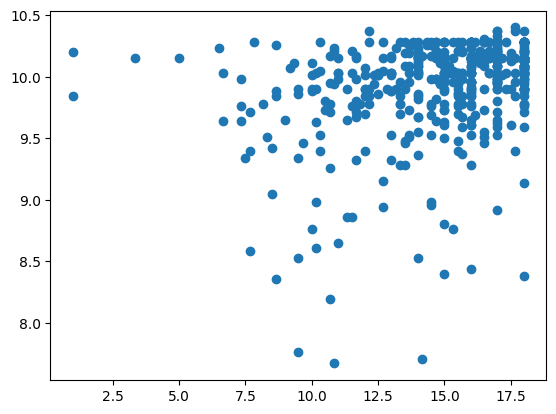

In [ ]:
data = pandas.read_csv("Grades.csv")
data = data[(data != 0).all(axis = 1)]
x = data["Exam"]
y = data["Quiz"]
plt.scatter(x, y)

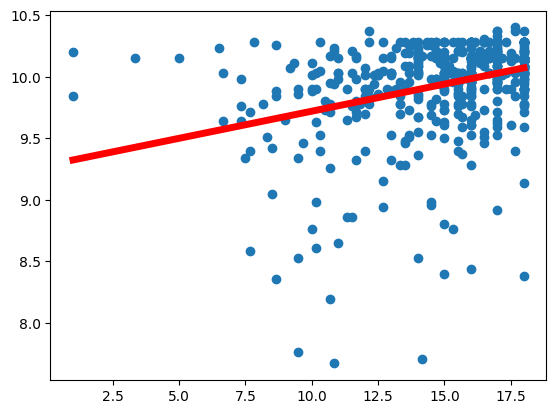

In [4]:
reg = sklearn.linear_model.LinearRegression()
x_mat = numpy.reshape(x, (-1, 1))
reg.fit(x_mat, y)
y_pred = reg.predict(x_mat)
plt.scatter(x, y)
plt.plot(x, y_pred, linewidth = 5, color = "red")

In [5]:
x_design = numpy.transpose(numpy.vstack([x, [1] * len(x)]))
w = scipy.linalg.lstsq(x_design, y)
[w[0], [reg.coef_, reg.intercept_]]

[array([0.04403661, 9.27941019]), [array([0.04403661]), 9.279410193539226]]

In [6]:
w0 = scipy.linalg.solve(numpy.transpose(x_design) @ x_design, numpy.transpose(x_design) @ y)
[w0, [reg.coef_, reg.intercept_]]

[array([0.04403661, 9.27941019]), [array([0.04403661]), 9.279410193539226]]

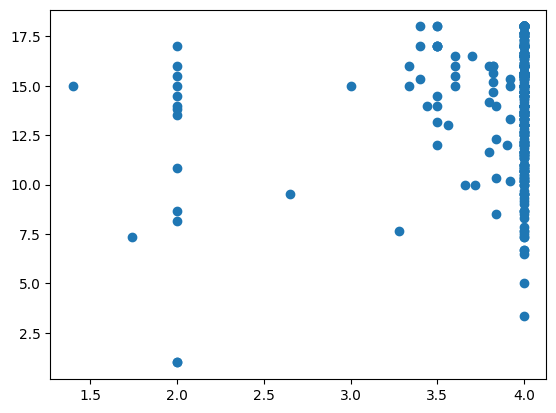

In [13]:
features = ["Project", "Quiz", "Labs"]
x = data[features]
y = data["Exam"]
plt.scatter(x["Project"], y)

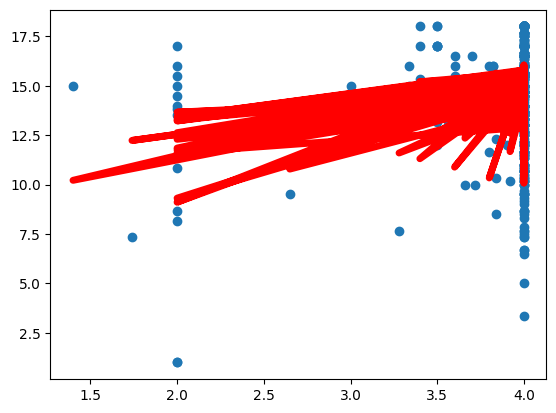

In [9]:
reg = sklearn.linear_model.LinearRegression()
reg.fit(x, y)
y_pred = reg.predict(x)
plt.scatter(x["Project"], y)
plt.plot(x["Project"], y_pred, linewidth = 5, color = "red")

In [10]:
x_design = numpy.hstack([x, numpy.transpose([1] * len(y)).reshape(-1, 1)])
w = scipy.linalg.lstsq(x_design, y)
[w[0], [reg.coef_, reg.intercept_]]

[array([  0.99895712,   2.04926504,   0.33347612, -10.92721262]),
 [array([0.99895712, 2.04926504, 0.33347612]), -10.927212622123541]]

In [11]:
w0 = scipy.linalg.solve(numpy.transpose(x_design) @ x_design, numpy.transpose(x_design) @ y)
[w0, [reg.coef_, reg.intercept_]]

[array([  0.99895712,   2.04926504,   0.33347612, -10.92721262]),
 [array([0.99895712, 2.04926504, 0.33347612]), -10.927212622123541]]

<BarContainer object of 3 artists>

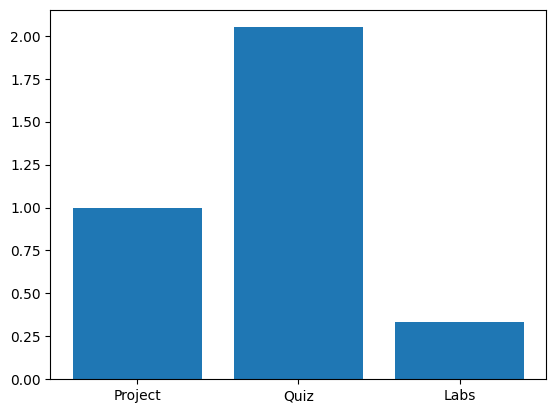

In [14]:
plt.bar(features, reg.coef_)

In [15]:
r2 = reg.score(x, y)
[r2, 1 - (1 - r2) * (len(y) - 1) / (len(y) - 5 - 1)]

[0.1322054801049778, 0.1232958854448647]

In [16]:
y_pred = reg.predict(x)
y_bar = numpy.mean(y)
(sum((y_pred - y_bar) ** 2)) / (sum((y - y_bar) ** 2))

0.132205480104977

<BarContainer object of 3 artists>

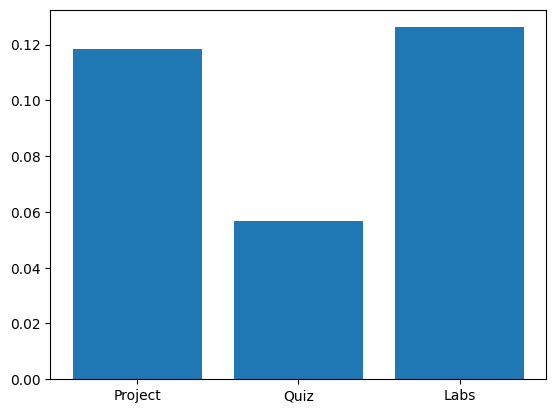

In [17]:
scores = []
for col in x:
    xi = x.drop(col, axis = 1)
    reg.fit(xi, y)
    scores.append(reg.score(xi, y))
plt.bar(features, scores)

In [19]:
model = statsmodels.api.OLS(y, statsmodels.api.add_constant(x)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     24.83
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           5.71e-15
Time:                        00:11:24   Log-Likelihood:                -1193.4
No. Observations:                 493   AIC:                             2395.
Df Residuals:                     489   BIC:                             2412.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.9272      3.130     -3.491      0.0